<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/difference_function_j%3D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

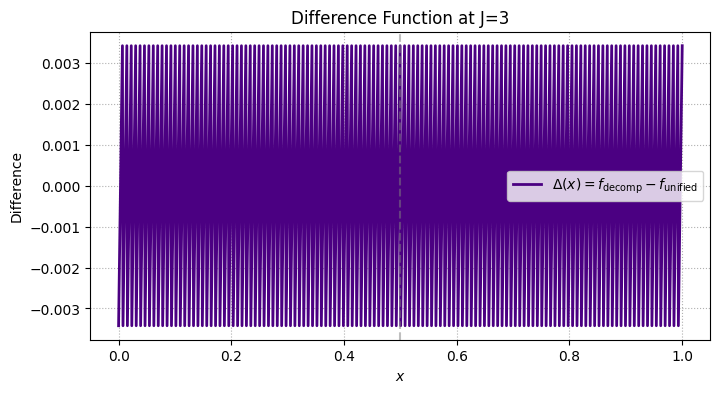

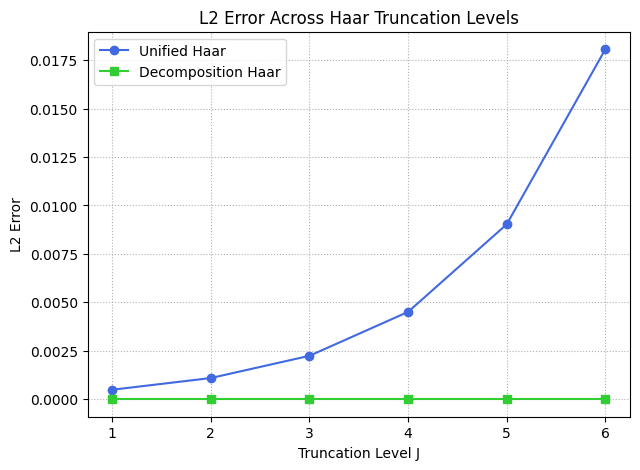

In [ ]:
# Haar Regularization Comparison in Google Colab
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Domain discretization
x = np.linspace(0, 1, 1024)
dx = x[1] - x[0]

# Smooth and discontinuous components
f_c = x
f_d = (x >= 0.5).astype(float)
f_true = f_c + f_d

# Haar truncation function
def haar_regularize(signal, level):
    coeffs = pywt.wavedec(signal, 'haar', level=level)
    coeffs_trunc = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    return pywt.waverec(coeffs_trunc, 'haar')[:len(signal)]

levels = np.arange(1, 7)
errors_u, errors_d = [], []

for J in levels:
    # Unified Haar approximation
    f_u = haar_regularize(f_true, level=J)

    # Decomposition-based Haar approximation
    f_d_reg = haar_regularize(f_d, level=J)
    f_decomp = f_c + f_d_reg

    # L2 errors
    e_u = np.sqrt(np.sum((f_true - f_u)**2) * dx)
    e_d = np.sqrt(np.sum((f_true - f_decomp)**2) * dx)
    errors_u.append(e_u)
    errors_d.append(e_d)

    # Difference visualization at J = 3
    if J == 3:
        delta = f_decomp - f_u
        plt.figure(figsize=(8,4))
        plt.plot(x, delta, color='indigo', linewidth=2,
                 label=r'$\Delta(x)=f_{\rm decomp}-f_{\rm unified}$')
        plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.5)
        plt.grid(True, linestyle=':')
        plt.xlabel('$x$')
        plt.ylabel('Difference')
        plt.legend()
        plt.title('Difference Function at J=3')
        plt.show()

# Error curves
plt.figure(figsize=(7,5))
plt.plot(levels, errors_u, '-o', label='Unified Haar', color='royalblue')
plt.plot(levels, errors_d, '-s', label='Decomposition Haar', color='limegreen')
plt.xlabel('Truncation Level J')
plt.ylabel('L2 Error')
plt.title('L2 Error Across Haar Truncation Levels')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()
